In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/cat vs dog.zip'

# Extract
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('raw_data')
    print(" complete!")
else:
    print(" not found.")

 complete!


In [ ]:
import os
import shutil
import random

base_dir = 'dataset'
sub_folders = [
    'train/cats', 'train/dogs',
    'test/cats', 'test/dogs'
]

for folder in sub_folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)
src_cat = 'raw_data/PetImages/Cat'
src_dog = 'raw_data/PetImages/Dog'

def organize_my_data(source, category):

    files = [f for f in os.listdir(source) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]


    random.shuffle(files)


    for i in range(800):
        shutil.copy(os.path.join(source, files[i]), f'dataset/train/{category}')

    for i in range(800, 1000):
        shutil.copy(os.path.join(source, files[i]), f'dataset/test/{category}')

# 4. Execution
try:
    print("Images organizing Please wait.")
    organize_my_data(src_cat, 'cats')
    organize_my_data(src_dog, 'dogs')
    print(" Folder structure 'dataset/' is ready.")


    print(f"Train Cats: {len(os.listdir('dataset/train/cats'))}")
    print(f"Test Cats: {len(os.listdir('dataset/test/cats'))}")
except Exception as e:
    print(f"Error: {e}. Check  'raw_data' .")

Images organizing Please wait.
 Folder structure 'dataset/' is ready.
Train Cats: 800
Test Cats: 200


**Step 1 – Import Libraries**
**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

**Step 2 – Data Pre-processing**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


train_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

test_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1280 images belonging to 2 classes.
Found 320 images belonging to 2 classes.


**Step 3 – Build CNN Model**

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5), # Task 1: Dropout layer added
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Step 4 – Compile Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Step 5 – Train the Model**

In [ ]:
# Task 2: Training for 20 epochs
history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.5102 - loss: 0.7070 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 322ms/step - accuracy: 0.5203 - loss: 0.6927 - val_accuracy: 0.5562 - val_loss: 0.6861
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 336ms/step - accuracy: 0.5430 - loss: 0.6887 - val_accuracy: 0.5562 - val_loss: 0.6850
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 320ms/step - accuracy: 0.5430 - loss: 0.6887 - val_accuracy: 0.5437 - val_loss: 0.6805
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 324ms/step - accuracy: 0.5844 - loss: 0.6804 - val_accuracy: 0.5500 - val_loss: 0.6821
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.5789 - loss: 0.6766 - val_accuracy: 0.6125 - val_loss: 0.6718
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.5820 - loss: 0.6783 - val_accuracy: 0.5781 - val_loss: 0.6765
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 316ms/step - accuracy: 0.5945 - loss: 0.6768 - val_accu

**Step 6 – Visualize Training Accuracy**

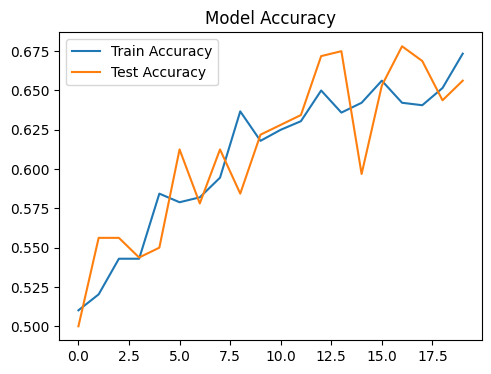

In [ ]:
# Accuracy Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title("Model Accuracy")
plt.legend()


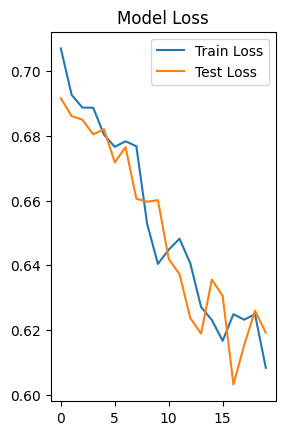

In [ ]:
# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title("Model Loss")
plt.legend()

plt.show()

**Step 7 – Test Model with New Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
Prediction: Cat


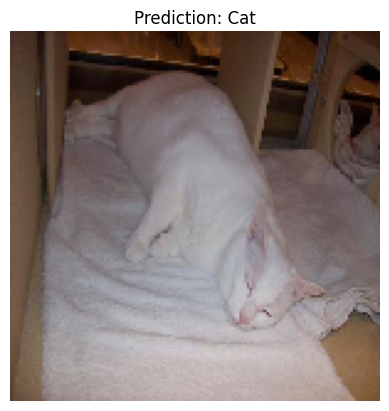

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
image_path = '/content/dataset/test/cats/1189.jpg'

img = image.load_img(image_path, target_size=(150,150))
img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0
prediction = model.predict(img_array)


if prediction[0][0] > 0.5:
    label = "Dog"
else:
    label = "Cat"

print("Prediction:", label)

plt.imshow(img)
plt.title("Prediction: " + label)
plt.axis("off")
plt.show()

In [ ]:
test_images = [
    '/content/dataset/train/dogs/10615.jpg',
    '/content/dataset/test/cats/12180.jpg',
    '/content/dataset/train/dogs/10596.jpg'
]

for img_path in test_images:
    img = image.load_img(img_path, target_size=(150,150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    prediction = model.predict(img_array)
    label = "Dog" if prediction[0][0] > 0.5 else "Cat"
    print(f"Image: {img_path} --> Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
Image: /content/dataset/train/dogs/10615.jpg --> Prediction: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Image: /content/dataset/test/cats/12180.jpg --> Prediction: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Image: /content/dataset/train/dogs/10596.jpg --> Prediction: Dog
